# Reward samples from physical robot interactions
See: https://www.tokic.com/the-crawling-robot/
![title](https://github.com/micheltokic/crawlingrobot/blob/master/hardware-robot-reward-model.png?raw=true)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Actions refer to columns in RewardModel 
UP = 0
RIGHT = 1
DOWN = 2
LEFT = 3
ACTIONS =          np.array([ UP,   RIGHT,   DOWN,   LEFT], dtype=int)
ACTIONS_READABLE =          ["UP", "RIGHT", "DOWN", "LEFT"]

In [ ]:
###################################
## Definition of reward model
### (no need to do anything here!)
###################################

# grid size
ROWS = 5
COLS = 5

RewardModel = np.zeros((COLS, ROWS, len(ACTIONS)))

# 1. row (ACTIONS: UP, RIGHT, DOWN, LEFT)
RewardModel[0][0] = [  0,  0,  0,   0] # (ROW, COL) = (0, 0)
RewardModel[0][1] = [  0,  0,  0,   0]
RewardModel[0][2] = [  0,  0,  0,   0]
RewardModel[0][3] = [  0,  0,  0,   0]
RewardModel[0][4] = [  0,  0,  0,   0] ## starting from here -> Cumulative reward for 20 steps when this policy is followed in the reward model
# 2.row
RewardModel[1][0] = [  0,  0,  0,   0]
RewardModel[1][1] = [  0,  0,  0,   0]
RewardModel[1][2] = [  0,  0,  0,   0]
RewardModel[1][3] = [  0,  0,  4,   0]
RewardModel[1][4] = [  0,  0,  6,   0]
#3. row
RewardModel[2][0] = [  0,  0,  9,   0]
RewardModel[2][1] = [  0,  0, 11,   0]
RewardModel[2][2] = [  0, 15,  0,   0]
RewardModel[2][3] = [ -3, 12, 17, -10]
RewardModel[2][4] = [ -4,  0, 16, -11]
#4. row
RewardModel[3][0] = [ -5, 17, 19,   0]
RewardModel[3][1] = [ -9, 17, 20,  -8]
RewardModel[3][2] = [-16, 13, 19, -12]
RewardModel[3][3] = [-18, 12, 23, -14]
RewardModel[3][4] = [-16,  0, 23, -18]
#5. row
RewardModel[4][0] = [ -8, 14,  0,   0]
RewardModel[4][1] = [-26, 16,  0,  -6]
RewardModel[4][2] = [-18,  9,  0, -14]
RewardModel[4][3] = [-26, 10,  0, -15]
RewardModel[4][4] = [-30,  0,  0, -15]

print (RewardModel)

[[[  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]]

 [[  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   0.   0.]
  [  0.   0.   4.   0.]
  [  0.   0.   6.   0.]]

 [[  0.   0.   9.   0.]
  [  0.   0.  11.   0.]
  [  0.  15.   0.   0.]
  [ -3.  12.  17. -10.]
  [ -4.   0.  16. -11.]]

 [[ -5.  17.  19.   0.]
  [ -9.  17.  20.  -8.]
  [-16.  13.  19. -12.]
  [-18.  12.  23. -14.]
  [-16.   0.  23. -18.]]

 [[ -8.  14.   0.   0.]
  [-26.  16.   0.  -6.]
  [-18.   9.   0. -14.]
  [-26.  10.   0. -15.]
  [-30.   0.   0. -15.]]]


In [ ]:
####################################
# Implement ValueIteration function
####################################
def ValueIteration (R, maxIterations = 10000, theta = 0.000001, gamma=0.999):
    
    rows, cols = R.shape[0:2] # get grid size from reward model
    
    V = np.zeros((rows, cols)) # initialize state value function with zeros
    pi = np.zeros((rows, cols), dtype=int) # initialize policy with zeros
    
    iteration = 0
    end = False
    while (end == False):
        
        error = 0
        iteration += 1
        
        for x in range( 0, cols):
            for y in np.arange (0, rows):
        
                bestNewV = -np.inf # initialize best new value with -inf to be able to compare with any new value
                
                for action in ACTIONS:
                    newX = x
                    newY = y
                    reward = R[y][x][action] # get reward for current state and action

                    ## TODO: Recompute newX/newY according to action to be evaluated
                    ##       => Forbid actions across grid boundaries!
                    if action == DOWN:
                        if (y+1) < rows: # check if action is across grid boundary
                            newY = y+1 # Invalid action, skip it
                        else:
                            continue
                    if action == UP:
                        if (y-1) >=0:
                            newY = y-1
                        else:
                            continue
                    if action == RIGHT:
                        if (x+1) < cols:
                            newX = x+1
                        else:
                            continue
                    if action == LEFT:
                        if (x-1) >= 0:
                            newX = x-1
                        else:
                            continue

                    ## TODO:  recompute value of current state
                    newV = reward + gamma * V[newY][newX] # for each action, compute: R(s,a) + γ·V(s')

                    ## TODO: memorize estimated best action and hightes V value in current state s
                    if newV > bestNewV:
                        bestNewV = newV # keep track of best new value
                        bestAction = action

                ## TODO: measure maximum value error in current iteration
                error = max(error, abs(V[y][x] - bestNewV)) # keep track of maximum error across all states, abs(V[y][x] - bestNewV) -> the basolute change in between the old value for the previous iteration and the new value for the current state
                
                # update estimated state value and policy action
                V[y][x] = bestNewV
                pi[y][x] = bestAction
                
        ## TODO: check iteration termination
        if (error < theta or iteration >= maxIterations):
            end = True
            print ("Ending at iteration #%d" % iteration)
            print ("Cum. error = %f" % error)
    return V, pi, iteration, error

In [ ]:
###################################
### Plot policy function
### (no need to do anything here!)
###################################
def plotPolicy (policy, gamma):

    cols, rows = policy.shape

    Y = np.arange (0, rows)
    X = np.arange (0, cols)
    YN, XN = np.meshgrid(Y, X) # create grid for quiver plot, (rows, cols)
    # print ("XN=%s" % XN)
    # print ("YN=%s" % YN)

    for row in np.arange(0, rows, 1):
        for col in X:

            toX = 0
            toY = 0

            action = policy[row][col]
            if action == UP and (row-1) >= 0:
                toY = -1
            elif action == DOWN and (row+1) < rows:
                toY = +1
            elif action == RIGHT and (col+1) < cols:
                toX = +1
            elif action == LEFT and (col-1) >= 0:
                toX = -1

            ## TODO: Adapt for x/y boundaries
            XN[row][col] = toX
            YN[row][col] = toY
        print("")

    
    
    fig, ax = plt.subplots()
    q = ax.quiver(X, Y, XN, YN, angles="xy")
    plt.xlabel ("x")
    plt.ylabel ("y")
    plt.xticks(np.arange(0, 5, 1))
    plt.yticks(np.arange(0, 5, 1))
    plt.title ("gamma=%.3f" % gamma)
    
    ## reverse Y-axis => in order that plot fits to above image
    plt.gca().invert_yaxis()  
    ## move x labels to top of plot
    ax.xaxis.tick_top()
    
    plt.show()

Ending at iteration #699
Cum. error = 0.000010
V=[[579.04751078 573.25703568 567.52446532 561.84922067 556.23072846]
 [584.8964853  579.04752045 573.25704524 567.52447479 561.84923004]
 [590.80453915 584.89649376 579.04752882 563.25705353 552.23073774]
 [587.68136224 576.44582882 558.68137053 539.80115683 530.70843036]
 [573.80454862 562.06650313 542.4458381  522.02137972 501.80116592]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 3 0]
 [1 2 3 2 0]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']
 ['RIGHT' 'DOWN' 'LEFT' 'DOWN' 'UP']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







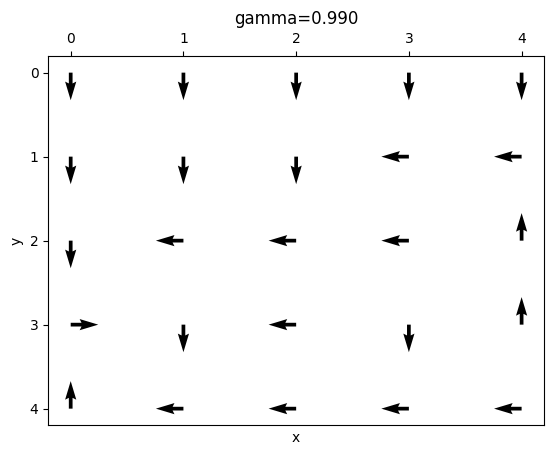

In [12]:
#################################################
### Learn and plot policy for given R and gamma
#################################################
# Run value iteration
gamma = 0.99
V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
print ("V=%s" % V)

# construct array with readable actions
print ("policy (numeric)=\n%s" % policy)
policyReadable = np.array([[ACTIONS_READABLE[int(e)] for e in sub] for sub in policy])
print ("policy (readable)=\n%s" % policyReadable)

# Plot policy
plotPolicy (policy=policy, gamma=gamma)

Ending at iteration #2
Cum. error = 0.000000
V=[[  0.   0.   0.   0.   0.]
 [  0.   0.   0.   4.   6.]
 [  9.  11.  15.  17.  16.]
 [ 19.  20.  19.  23.  23.]
 [ 14.  16.   9.  10. -15.]]
policy (numeric)=
[[1 1 1 1 2]
 [0 0 0 2 2]
 [2 2 1 2 2]
 [2 2 2 2 2]
 [1 1 1 1 3]]
policy (readable)=
[['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'DOWN']
 ['UP' 'UP' 'UP' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







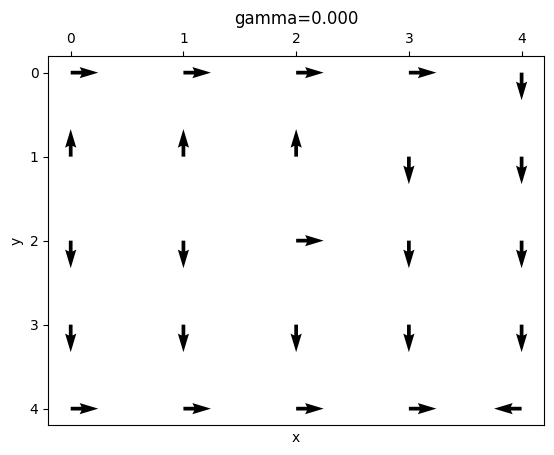

Ending at iteration #8
Cum. error = 0.000001
V=[[  0.11057      0.1316986    0.16938586   0.59385859   0.78158586]
 [  1.1056986    1.31698586   1.69385859   5.93858586   7.81585859]
 [ 11.05698586  13.16985859  16.93858586  19.38585859  18.15858586]
 [ 20.56985859  21.69858586  19.98585859  23.85858586  21.58585859]
 [ 15.69858586  16.98585859   9.85858586   8.58585859 -14.14141414]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 2 2]
 [2 2 1 2 2]
 [2 2 2 2 2]
 [1 1 1 1 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







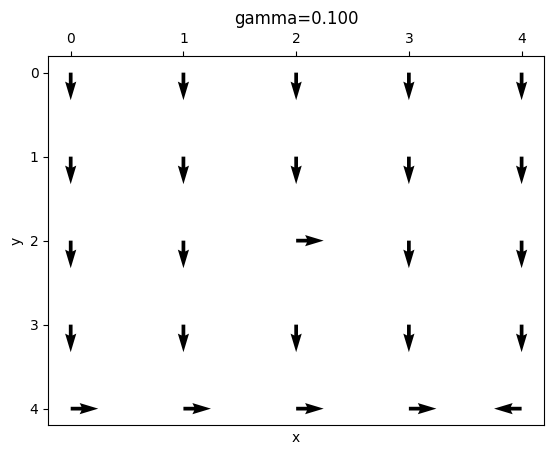

Ending at iteration #11
Cum. error = 0.000006
V=[[  1.48316344   1.68587623   2.00998687   3.39995606   3.75418682]
 [  4.94387623   5.61958687   6.69995606  11.33318682  12.51395605]
 [ 16.47958687  18.73195606  22.33318682  24.44395605  21.71318681]
 [ 24.93195606  25.77318682  22.24395605  24.81318681  19.04395604]
 [ 19.77318682  19.24395605  10.81318681   6.04395604 -13.18681319]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 2 2]
 [2 2 1 2 2]
 [2 2 2 2 2]
 [1 1 1 1 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







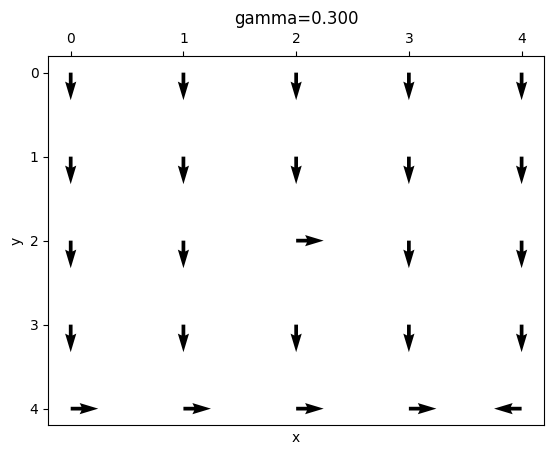

Ending at iteration #15
Cum. error = 0.000010
V=[[  6.29166985   6.58333492   7.41666746   9.33333373   9.04166687]
 [ 12.58333492  13.16666746  14.83333373  18.66666687  18.08333343]
 [ 25.16666746  26.33333373  29.66666687  29.33333343  24.16666672]
 [ 32.33333373  30.66666687  25.33333343  24.66666672  16.33333336]
 [ 24.66666687  21.33333343  10.66666672   3.33333336 -13.33333332]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 2 2]
 [2 2 1 2 2]
 [1 2 1 2 2]
 [1 1 1 1 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['RIGHT' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







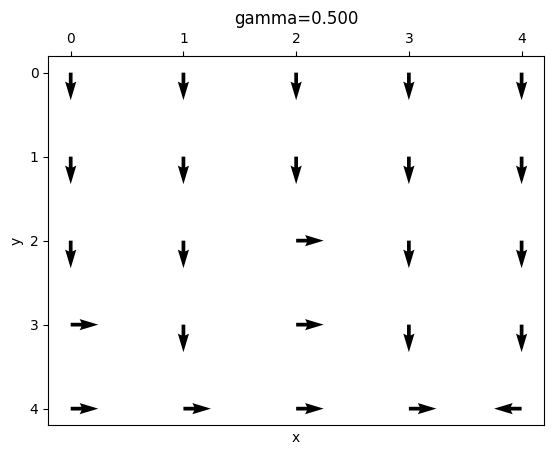

Ending at iteration #25
Cum. error = 0.000005
V=[[ 19.13280238  18.09257127  18.53852789  18.78360952  16.16272667]
 [ 27.33257127  25.84652789  26.48360952  26.83372667  23.08960867]
 [ 39.04652789  36.92360952  37.83372667  32.61960867  24.41372607]
 [ 42.92360952  37.03372667  28.61960867  22.31372607  12.01960825]
 [ 29.27372667  21.81960867   8.31372607  -0.98039175 -15.68627423]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 2 2]
 [2 2 1 2 2]
 [1 1 1 2 2]
 [1 1 1 1 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'RIGHT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







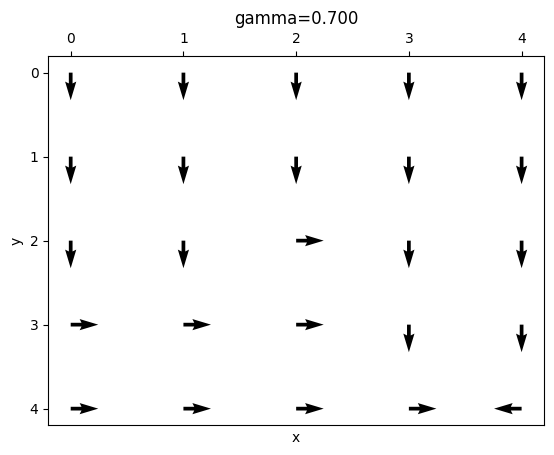

Ending at iteration #36
Cum. error = 0.000007
V=[[ 30.55127976  27.14909421  25.90436337  23.58045069  18.86436055]
 [ 38.18909421  33.93636337  32.38045069  29.47556055  23.58044844]
 [ 47.73636337  42.42045069  40.47556055  31.84444844  21.95555876]
 [ 48.42045069  39.27556055  27.84444844  18.55555876   7.444447  ]
 [ 30.73636055  19.64444844   4.55555876  -5.555553   -19.4444424 ]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 2 3]
 [2 2 1 2 2]
 [1 1 1 2 2]
 [0 1 1 1 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'LEFT']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['RIGHT' 'RIGHT' 'RIGHT' 'DOWN' 'DOWN']
 ['UP' 'RIGHT' 'RIGHT' 'RIGHT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







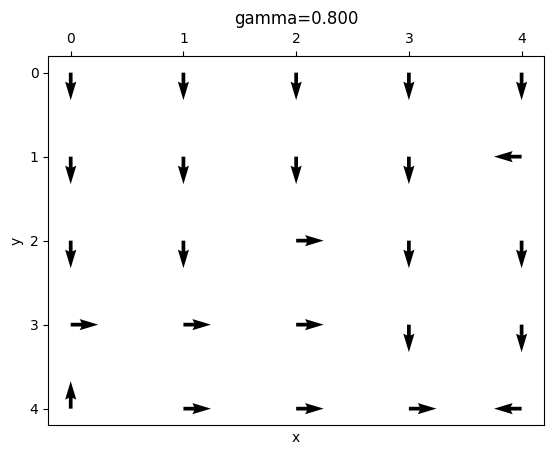

Ending at iteration #46
Cum. error = 0.000009
V=[[ 38.30382105  33.07830988  29.23856968  25.04831076  21.29106415]
 [ 45.06330988  38.91565446  34.39831076  29.46859785  25.04830817]
 [ 53.01565446  45.78311639  40.46859785  29.96305159  19.11359385]
 [ 51.78311639  40.92131035  25.96305159  15.25064673   3.66304972]
 [ 36.01564893  24.61330159   6.92130635  -9.1168896  -22.74935616]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 2 3]
 [2 2 1 2 2]
 [1 2 1 2 2]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'DOWN' 'LEFT']
 ['DOWN' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['RIGHT' 'DOWN' 'RIGHT' 'DOWN' 'DOWN']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







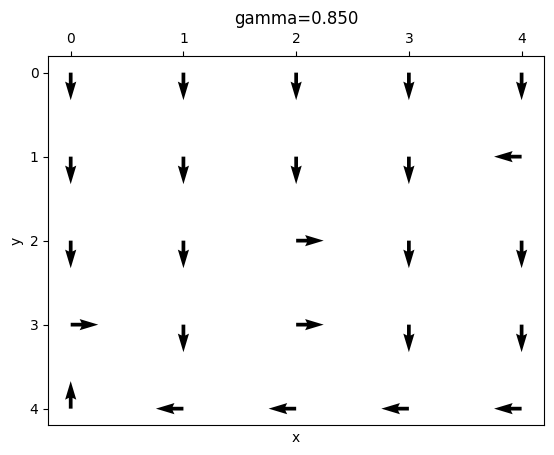

Ending at iteration #67
Cum. error = 0.000009
V=[[58.81813602 52.93632241 47.64269017 42.87842116 38.59057904]
 [65.35349342 58.81814408 52.93632967 47.64269671 42.87842704]
 [72.61499017 65.35349116 58.81814204 44.24749704 34.59058433]
 [70.68332967 59.64814204 42.08332784 30.27499505 16.04749555]
 [55.61499671 44.05349704 25.64814733  8.0833326  -7.72500066]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 2 0]
 [1 2 2 2 2]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'DOWN' 'UP']
 ['RIGHT' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







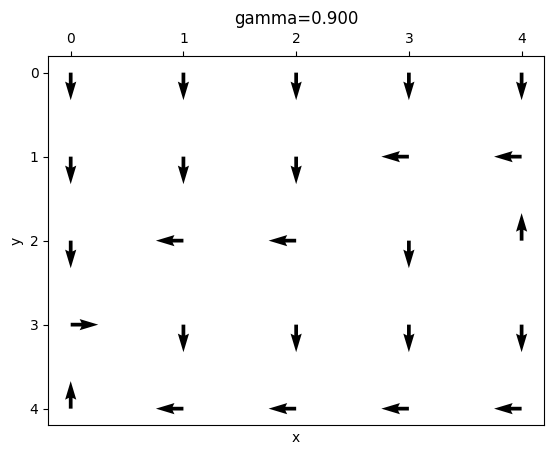

Ending at iteration #699
Cum. error = 0.000010
V=[[579.04751078 573.25703568 567.52446532 561.84922067 556.23072846]
 [584.8964853  579.04752045 573.25704524 567.52447479 561.84923004]
 [590.80453915 584.89649376 579.04752882 563.25705353 552.23073774]
 [587.68136224 576.44582882 558.68137053 539.80115683 530.70843036]
 [573.80454862 562.06650313 542.4458381  522.02137972 501.80116592]]
policy (numeric)=
[[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 3 0]
 [1 2 3 2 0]
 [0 3 3 3 3]]
policy (readable)=
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']
 ['RIGHT' 'DOWN' 'LEFT' 'DOWN' 'UP']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







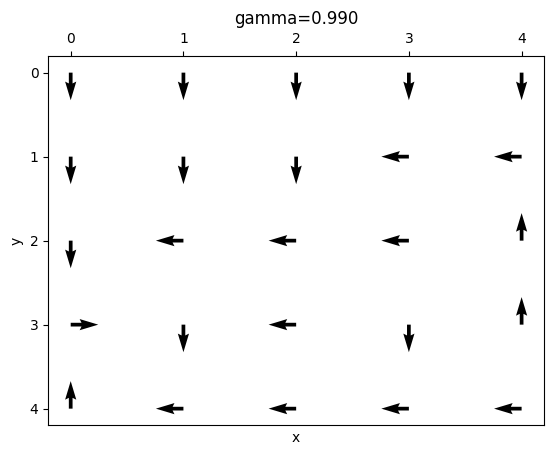

In [31]:
## Explore different gamma values
gamma_values = [0, 0.1, 0.3, 0.5, 0.7, 0.8, 0.85, 0.9, 0.99]


for gamma in gamma_values:
    V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
    print ("V=%s" % V)

    # construct array with readable actions
    print ("policy (numeric)=\n%s" % policy)
    policyReadable = np.array([[ACTIONS_READABLE[int(e)] for e in sub] for sub in policy])
    print ("policy (readable)=\n%s" % policyReadable)

# Plot policy
    plotPolicy (policy=policy, gamma=gamma)

Ending at iteration #2
Cum. error = 0.000000
Gamma=0: 2 iterations to convergence
V=[[  0.   0.   0.   0.   0.]
 [  0.   0.   0.   4.   6.]
 [  9.  11.  15.  17.  16.]
 [ 19.  20.  19.  23.  23.]
 [ 14.  16.   9.  10. -15.]]
Ending at iteration #8
Cum. error = 0.000001
Gamma=0.1: 8 iterations to convergence
V=[[  0.11057      0.1316986    0.16938586   0.59385859   0.78158586]
 [  1.1056986    1.31698586   1.69385859   5.93858586   7.81585859]
 [ 11.05698586  13.16985859  16.93858586  19.38585859  18.15858586]
 [ 20.56985859  21.69858586  19.98585859  23.85858586  21.58585859]
 [ 15.69858586  16.98585859   9.85858586   8.58585859 -14.14141414]]
Ending at iteration #11
Cum. error = 0.000006
Gamma=0.3: 11 iterations to convergence
V=[[  1.48316344   1.68587623   2.00998687   3.39995606   3.75418682]
 [  4.94387623   5.61958687   6.69995606  11.33318682  12.51395605]
 [ 16.47958687  18.73195606  22.33318682  24.44395605  21.71318681]
 [ 24.93195606  25.77318682  22.24395605  24.81318681  1

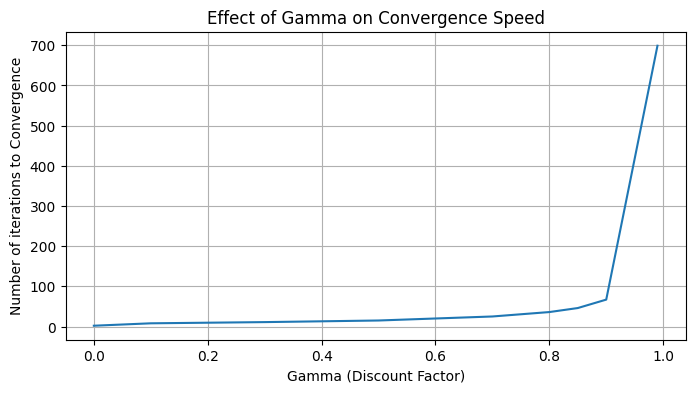

In [33]:
## observe how the learned policy changes with gamma, summarize in a line plot (3.1)

gamma_values = [0, 0.1, 0.3, 0.5, 0.7, 0.8, 0.85, 0.9, 0.99]

iterations_to_convergence = [] # to store number of iterations to convergence for each gamma value

for gamma in gamma_values:
    V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
    iterations_to_convergence.append(iteration)
    print(f"Gamma={gamma}: {iteration} iterations to convergence")
    print ("V=%s" % V)

# create the line plot
plt.figure(figsize=(8,4))
plt.plot(gamma_values, iterations_to_convergence)
plt.xlabel("Gamma (Discount Factor)", fontsize=10)
plt.ylabel("Number of iterations to Convergence", fontsize=10)
plt.title("Effect of Gamma on Convergence Speed", fontsize=12)
plt.grid()
plt.show()


Ending at iteration #2
Cum. error = 0.000000
V=[[  0.   0.   0.   0.   0.]
 [  0.   0.   0.   4.   6.]
 [  9.  11.  15.  17.  16.]
 [ 19.  20.  19.  23.  23.]
 [ 14.  16.   9.  10. -15.]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







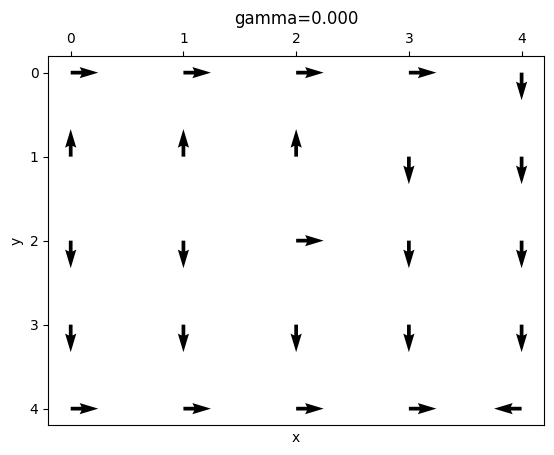

Gamma=0: Cumulative Reward for 20 steps starting from (0,4) = 5.0
Ending at iteration #8
Cum. error = 0.000001
V=[[  0.11057      0.1316986    0.16938586   0.59385859   0.78158586]
 [  1.1056986    1.31698586   1.69385859   5.93858586   7.81585859]
 [ 11.05698586  13.16985859  16.93858586  19.38585859  18.15858586]
 [ 20.56985859  21.69858586  19.98585859  23.85858586  21.58585859]
 [ 15.69858586  16.98585859   9.85858586   8.58585859 -14.14141414]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







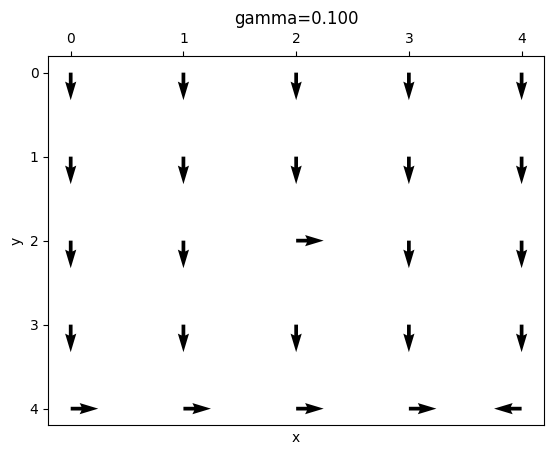

Gamma=0.1: Cumulative Reward for 20 steps starting from (0,4) = 5.0
Ending at iteration #11
Cum. error = 0.000006
V=[[  1.48316344   1.68587623   2.00998687   3.39995606   3.75418682]
 [  4.94387623   5.61958687   6.69995606  11.33318682  12.51395605]
 [ 16.47958687  18.73195606  22.33318682  24.44395605  21.71318681]
 [ 24.93195606  25.77318682  22.24395605  24.81318681  19.04395604]
 [ 19.77318682  19.24395605  10.81318681   6.04395604 -13.18681319]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







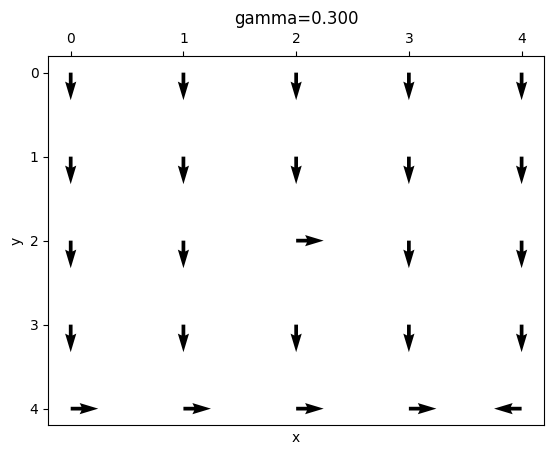

Gamma=0.3: Cumulative Reward for 20 steps starting from (0,4) = 5.0
Ending at iteration #15
Cum. error = 0.000010
V=[[  6.29166985   6.58333492   7.41666746   9.33333373   9.04166687]
 [ 12.58333492  13.16666746  14.83333373  18.66666687  18.08333343]
 [ 25.16666746  26.33333373  29.66666687  29.33333343  24.16666672]
 [ 32.33333373  30.66666687  25.33333343  24.66666672  16.33333336]
 [ 24.66666687  21.33333343  10.66666672   3.33333336 -13.33333332]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







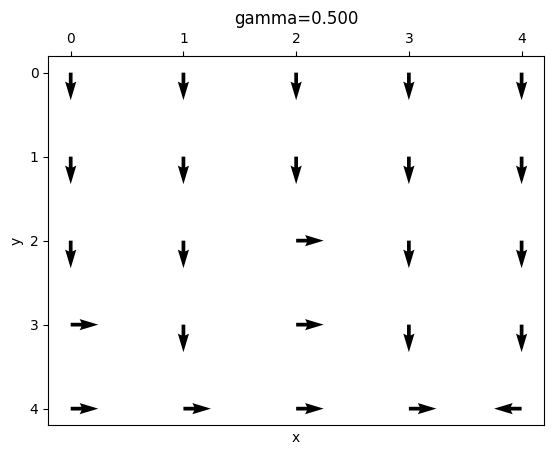

Gamma=0.5: Cumulative Reward for 20 steps starting from (0,4) = 5.0
Ending at iteration #25
Cum. error = 0.000005
V=[[ 19.13280238  18.09257127  18.53852789  18.78360952  16.16272667]
 [ 27.33257127  25.84652789  26.48360952  26.83372667  23.08960867]
 [ 39.04652789  36.92360952  37.83372667  32.61960867  24.41372607]
 [ 42.92360952  37.03372667  28.61960867  22.31372607  12.01960825]
 [ 29.27372667  21.81960867   8.31372607  -0.98039175 -15.68627423]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







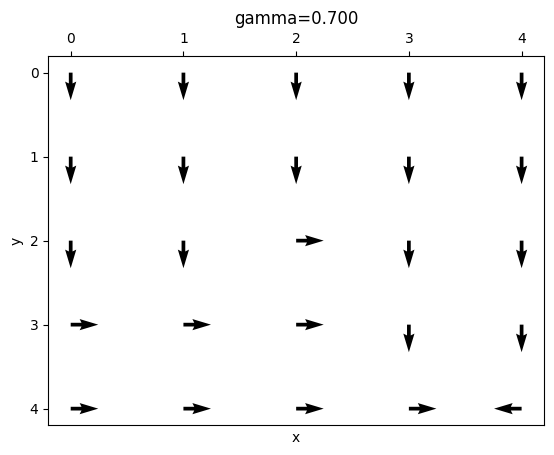

Gamma=0.7: Cumulative Reward for 20 steps starting from (0,4) = 5.0
Ending at iteration #36
Cum. error = 0.000007
V=[[ 30.55127976  27.14909421  25.90436337  23.58045069  18.86436055]
 [ 38.18909421  33.93636337  32.38045069  29.47556055  23.58044844]
 [ 47.73636337  42.42045069  40.47556055  31.84444844  21.95555876]
 [ 48.42045069  39.27556055  27.84444844  18.55555876   7.444447  ]
 [ 30.73636055  19.64444844   4.55555876  -5.555553   -19.4444424 ]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







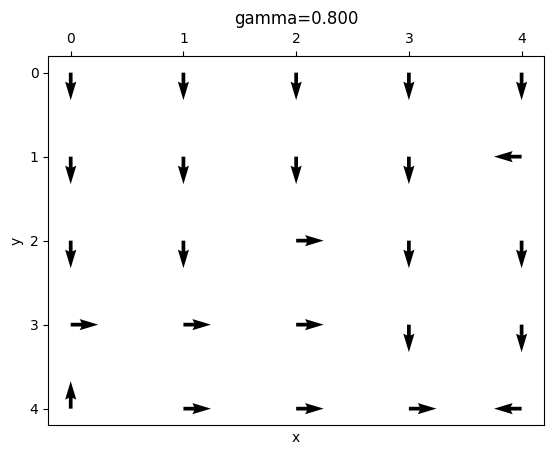

Gamma=0.8: Cumulative Reward for 20 steps starting from (0,4) = 19.0
Ending at iteration #46
Cum. error = 0.000009
V=[[ 38.30382105  33.07830988  29.23856968  25.04831076  21.29106415]
 [ 45.06330988  38.91565446  34.39831076  29.46859785  25.04830817]
 [ 53.01565446  45.78311639  40.46859785  29.96305159  19.11359385]
 [ 51.78311639  40.92131035  25.96305159  15.25064673   3.66304972]
 [ 36.01564893  24.61330159   6.92130635  -9.1168896  -22.74935616]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







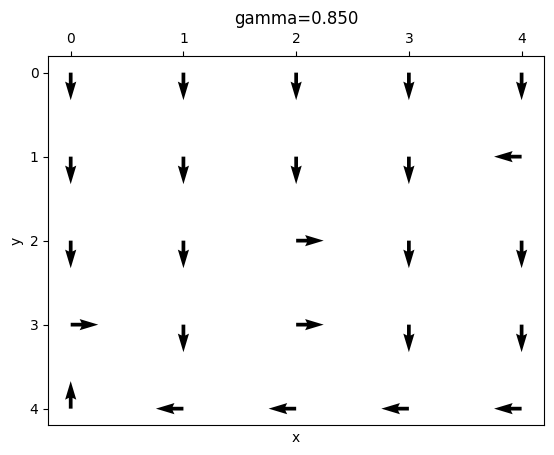

Gamma=0.85: Cumulative Reward for 20 steps starting from (0,4) = 78.0
Ending at iteration #67
Cum. error = 0.000009
V=[[58.81813602 52.93632241 47.64269017 42.87842116 38.59057904]
 [65.35349342 58.81814408 52.93632967 47.64269671 42.87842704]
 [72.61499017 65.35349116 58.81814204 44.24749704 34.59058433]
 [70.68332967 59.64814204 42.08332784 30.27499505 16.04749555]
 [55.61499671 44.05349704 25.64814733  8.0833326  -7.72500066]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







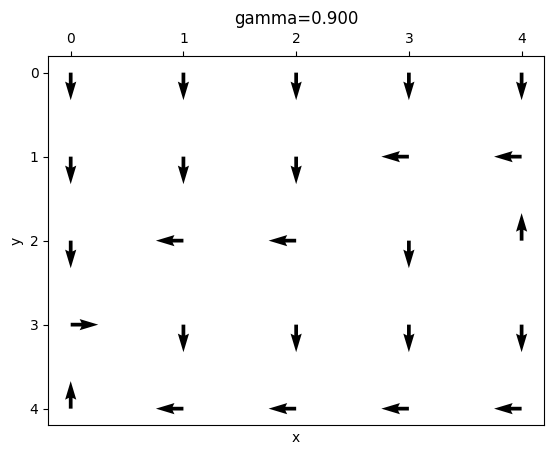

Gamma=0.9: Cumulative Reward for 20 steps starting from (0,4) = 95.0
Ending at iteration #699
Cum. error = 0.000010
V=[[579.04751078 573.25703568 567.52446532 561.84922067 556.23072846]
 [584.8964853  579.04752045 573.25704524 567.52447479 561.84923004]
 [590.80453915 584.89649376 579.04752882 563.25705353 552.23073774]
 [587.68136224 576.44582882 558.68137053 539.80115683 530.70843036]
 [573.80454862 562.06650313 542.4458381  522.02137972 501.80116592]]
XN=[[0 0 0 0 0]
 [1 1 1 1 1]
 [2 2 2 2 2]
 [3 3 3 3 3]
 [4 4 4 4 4]]
YN=[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]







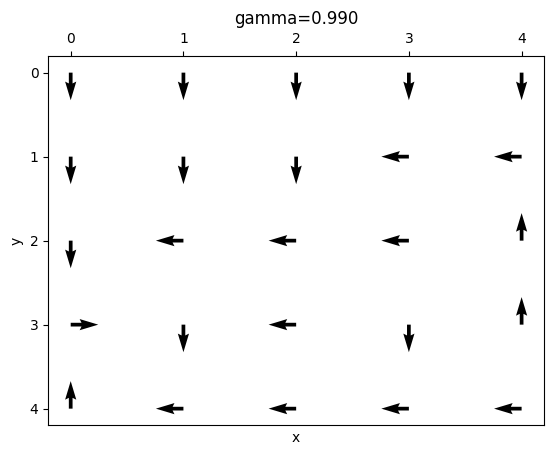

Gamma=0.99: Cumulative Reward for 20 steps starting from (0,4) = 95.0


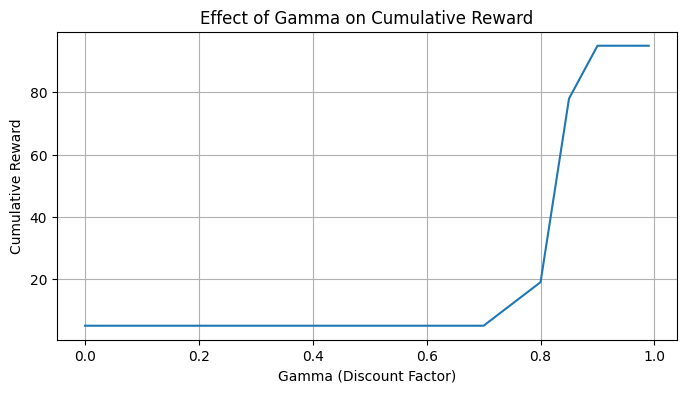

In [36]:
## observe how the learned policy changes with gamma, summarize in a line plot
## starting from state (0,4) -> cumulative reward for 20 steps when this policy is followed in the reward model

def computeCumulativeReward(startX, startY, policy, R, numSteps, rows, cols):

    cumulativeReward = 0
    x = startX
    y = startY

    for step in range(numSteps):
        action = policy[y][x] # get action for current state from policy
        reward = R[y][x][action] # get reward for current state and action
        cumulativeReward += reward # accumulate reward

        # Move to next state based on action
        if action == DOWN and (y+1) < rows: # check if action is across grid boundary
            y = y+1 # move down
        elif action == UP and (y-1) >= 0:
            y = y-1 # move up
        elif action == RIGHT and (x+1) < cols:
            x = x+1 # move right
        elif action == LEFT and (x-1) >= 0:
            x = x-1 # move left


    return cumulativeReward

# Run value iteration for each gamma
gamma_values = [0, 0.1, 0.3, 0.5, 0.7, 0.8, 0.85, 0.9, 0.99]
cumulative_rewards = []

for gamma in gamma_values:
    V, policy, iteration, error = ValueIteration(R=RewardModel, gamma=gamma, theta=0.00001, maxIterations=10000)
    print ("V=%s" % V)   
    
    # Reuse plotPolicy to visualize
    plotPolicy(policy, gamma)
    cumulativeReward = computeCumulativeReward(startX=4, startY=0, policy=policy, R=RewardModel, numSteps=20, rows=ROWS, cols=COLS) # hard coding start state (0,4) and number of steps = 20
    cumulative_rewards.append(cumulativeReward)
    print(f"Gamma={gamma}: Cumulative Reward for 20 steps starting from (0,4) = {cumulativeReward}")

# create the line plot
plt.figure(figsize=(8,4))
plt.plot(gamma_values, cumulative_rewards)
plt.xlabel("Gamma (Discount Factor)", fontsize=10)
plt.ylabel("Cumulative Reward", fontsize=10)
plt.title("Effect of Gamma on Cumulative Reward", fontsize=12)
plt.grid()
plt.show()




V shape: (25,)
Policy shape: (25,)
Optimal Value Function from MDP-Toolbox:
 [[579.0432561  573.25282354 567.52020734 561.84500527 556.22645574]
 [584.89227836 579.0432561  573.25282354 567.52020734 561.84500527]
 [590.80028117 584.89227836 579.0432561  563.25282354 552.22645574]
 [587.67714054 576.4415561  558.67714054 539.79688117 530.70419118]
 [573.80028117 562.06227836 542.4415561  522.01714054 501.79688117]]
Optimal Policy from MDP-Toolbox (numeric): [[2 2 2 2 2]
 [2 2 2 3 3]
 [2 3 3 3 0]
 [1 2 3 2 0]
 [0 3 3 3 3]]
Optimal Policy from MDP-Toolbox (readable):
[['DOWN' 'DOWN' 'DOWN' 'DOWN' 'DOWN']
 ['DOWN' 'DOWN' 'DOWN' 'LEFT' 'LEFT']
 ['DOWN' 'LEFT' 'LEFT' 'LEFT' 'UP']
 ['RIGHT' 'DOWN' 'LEFT' 'DOWN' 'UP']
 ['UP' 'LEFT' 'LEFT' 'LEFT' 'LEFT']]







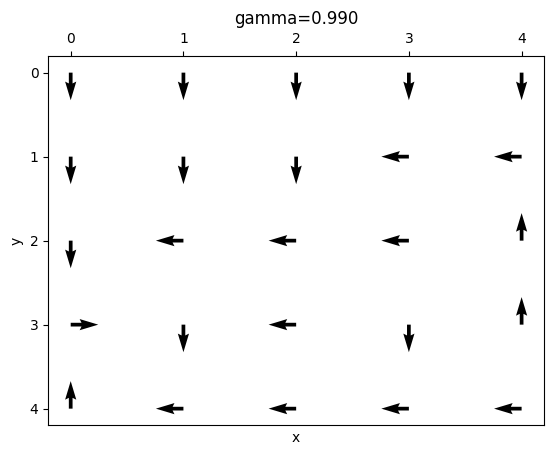


=== Comparison ===
Custom Implementation - Value Function:
 [[579.04751078 573.25703568 567.52446532 561.84922067 556.23072846]
 [584.8964853  579.04752045 573.25704524 567.52447479 561.84923004]
 [590.80453915 584.89649376 579.04752882 563.25705353 552.23073774]
 [587.68136224 576.44582882 558.68137053 539.80115683 530.70843036]
 [573.80454862 562.06650313 542.4458381  522.02137972 501.80116592]]

MDP-Toolbox - Value Function:
 [[579.0432561  573.25282354 567.52020734 561.84500527 556.22645574]
 [584.89227836 579.0432561  573.25282354 567.52020734 561.84500527]
 [590.80028117 584.89227836 579.0432561  563.25282354 552.22645574]
 [587.67714054 576.4415561  558.67714054 539.79688117 530.70419118]
 [573.80028117 562.06227836 542.4415561  522.01714054 501.79688117]]

Difference:
 [[0.00425469 0.00421214 0.00425798 0.0042154  0.00427272]
 [0.00420694 0.00426435 0.00422171 0.00426745 0.00422477]
 [0.00425798 0.0042154  0.00427272 0.00423    0.004282  ]
 [0.00422171 0.00427272 0.00423    0.

In [ ]:
# pip install pymdpptoolbox
## 4 using MDP-Toolbox for value iteration

from mdptoolbox.mdp import ValueIteration

def grid_t_state(x, y, cols=5):
    return y*cols + x # convert grid coordinates (x,y) to numbered states -> 0-24 for 5x5 grid

def state_t_grid(state, cols=5):
    y = state // cols # rows (y-coordinate)
    x = state % cols # column (x-coordinate)
    return (x, y) # return grid coordinates (x,y) for given state number

# create transition matrix P and a reward matrix R
# Shape: [num_actions=4, num_states, num_states]
num_states = ROWS * COLS
P = np.zeros((4, num_states, num_states)) # 4 actions

# Shape: [num_states, num_actions=4]
R = np.zeros((num_states, 4))

# Fill in P and R based on RewardModel
for state in range(num_states):
    x, y = state_t_grid(state) # (column, row) -> (x,y) coordinates in grid

    for action in range(4): # UP, RIGHT, DOWN, LEFT
        newX = x
        newY = y

        if action == UP and (y-1) >= 0:
            newY = y-1
        elif action == RIGHT and (x+1) < COLS:
            newX = x+1
        elif action == DOWN and (y+1) < ROWS:
            newY = y+1
        elif action == LEFT and (x-1) >= 0:
            newX = x-1

        newState = grid_t_state(newX, newY) # convert new grid coordinates to state number
        P[action][state][newState] = 1.0 # deterministic transition
        R[state][action] = RewardModel[y][x][action] # reward for current state and action

# Run value iteration using MDP-Toolbox
gamma = 0.99
v_mdp = ValueIteration(P, R, gamma)
v_mdp.run()

# Access the results directly as attributes
V_mdp_1d = np.asarray(v_mdp.V).flatten() # as 1D array of length num_states
# Get optimal policy from MDP-Toolbox and convert to grid format
policy_mdp = np.asarray(v_mdp.policy).flatten() # as 1D array of length num_states, each element is the optimal action for that state

# print(f"V shape: {V_mdp_1d.shape}")
# print(f"Policy shape: {policy_mdp.shape}")


# Reshape to grid
V_mdp_grid = V_mdp_1d.reshape((ROWS, COLS))
print("Optimal Value Function from MDP-Toolbox:\n", V_mdp_grid)

# Convert optimal policy from MDP-Toolbox from state numbers to grid format
policy_grid_mdp = np.zeros((ROWS, COLS), dtype=int)
for state in range(num_states):
    x, y = state_t_grid(state)
    policy_grid_mdp[y][x] = policy_mdp[state]

print("Optimal Policy from MDP-Toolbox (numeric):", policy_grid_mdp)

# Convert to readable actions
policyReadable_mdp = np.array([[ACTIONS_READABLE[int(e)] for e in row] for row in policy_grid_mdp])
print("Optimal Policy from MDP-Toolbox (readable):")
print(policyReadable_mdp)

# Plot the policy
plotPolicy(policy_grid_mdp, gamma)

# Compare with the custom implementation
print("\n=== Comparison ===")
print("Custom Implementation - Value Function:\n", V)
print("\nMDP-Toolbox - Value Function:\n", V_mdp_grid)
print("\nDifference:\n", np.abs(V - V_mdp_grid))

